In [1]:
import os
os.chdir('../../')

In [8]:
!ls logs/ablations/multi3/s5

events.out.tfevents.1756480061.cc8aa178d5bc.29558.0  step_00010000.pt
step_00000000.pt				     step_00011000.pt
step_00001000.pt				     step_00012000.pt
step_00002000.pt				     step_00013000.pt
step_00003000.pt				     step_00014000.pt
step_00004000.pt				     step_00015000.pt
step_00005000.pt				     step_00016000.pt
step_00006000.pt				     step_00017000.pt
step_00007000.pt				     step_00018000.pt
step_00008000.pt				     step_00019000.pt
step_00009000.pt				     step_00020000.pt


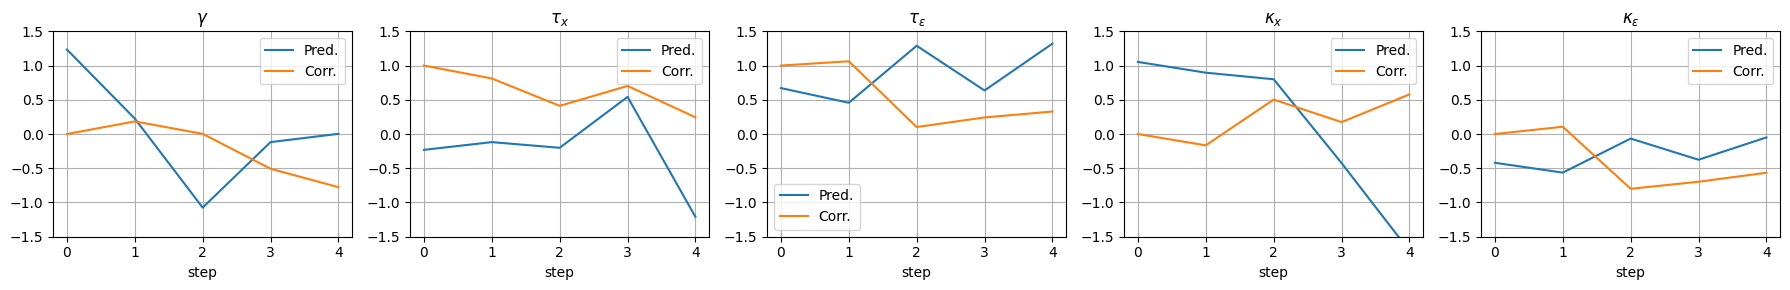

In [44]:
import torch, numpy as np, matplotlib.pyplot as plt

PATH  = 'logs/ablations/multi3/s5/step_00020000.pt'
tab   = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
x     = np.arange(tab.shape[0])

fig, ax = plt.subplots(1, 5, figsize=(18, 3), sharex=True)

params = [
    (0, r'$\gamma$',          lambda a: a),
    (1, r'$\tau_x$',          lambda a: 1.0 + a),
    (2, r'$\tau_{\varepsilon}$', lambda a: 1.0 + a),   # tau_epsilon
    (3, r'$\kappa_x$',        lambda a: a),
    (4, r'$\kappa_{\varepsilon}$', lambda a: a),       # kappa_epsilon
]

for k, (idx, title, f) in enumerate(params):
    ax[k].plot(x, f(tab[:, 0, idx]), label='Pred.')
    ax[k].plot(x, f(tab[:, 1, idx]), label='Corr.')
    ax[k].set_ylim([-1.5, 1.5])
    ax[k].set_title(title)
    ax[k].set_xlabel('step')
    ax[k].grid(True)
    ax[k].legend()

fig.tight_layout()
plt.show()

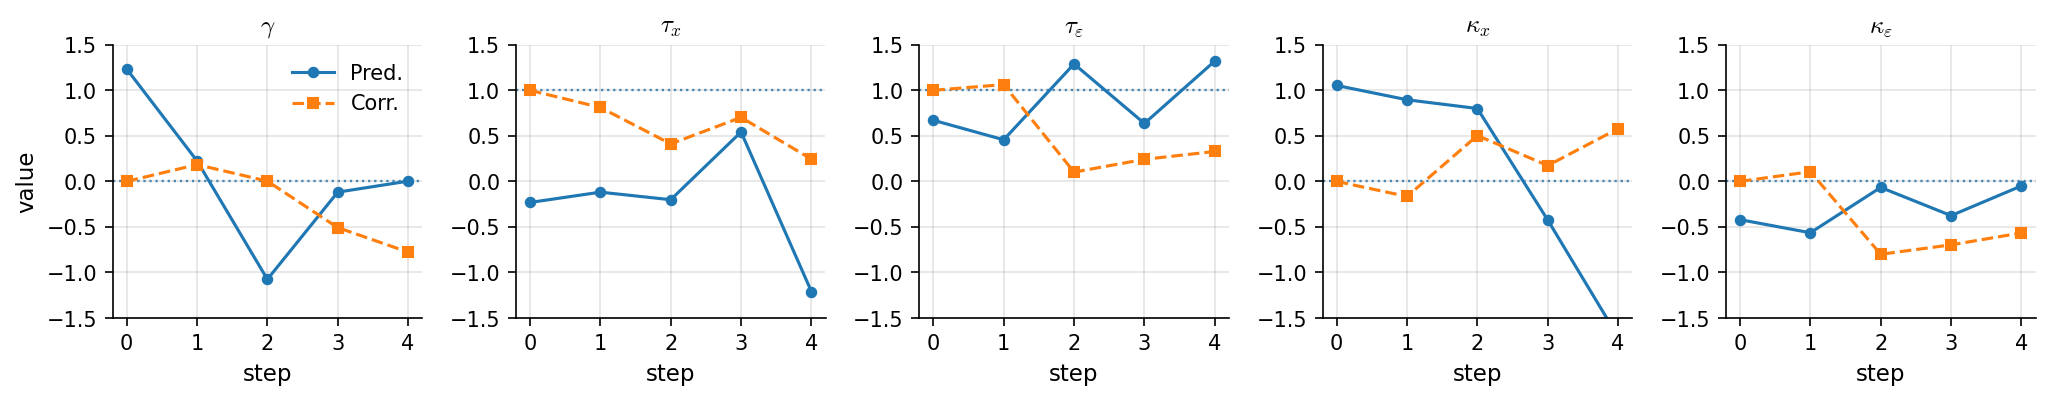

In [57]:
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- Load ----------
PATH  = 'logs/ablations/multi3/s5/step_00020000.pt'
tab   = torch.load(PATH, map_location='cpu')['solver_state_dict']['param_extractor.table'].float().numpy()  # [S,2,P]
x     = np.arange(tab.shape[0])  # 0..S-1 (step index)

# ---------- Style (ICLR-ready) ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,                    # 본문 크기
    "axes.titlesize": 12,               # 서브플롯 제목
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.35,
    "mathtext.fontset": "cm",           # Computer Modern 수학 폰트
})

fig, ax = plt.subplots(1, 5, figsize=(13.8, 2.8), sharex=True)  # 넓이 줄여 논문 칼럼폭에 맞춤

# (index, title, transform, refline)
params = [
    (0, r'$\gamma$',              lambda a: a,          0.0),
    (1, r'$\tau_x$',              lambda a: 1.0 + a,    1.0),
    (2, r'$\tau_{\varepsilon}$',  lambda a: 1.0 + a,    1.0),
    (3, r'$\kappa_x$',            lambda a: a,          0.0),
    (4, r'$\kappa_{\varepsilon}$',lambda a: a,          0.0),
]

# 공통 라인 스타일
lw = 1.5
ms = 4.5

for k, (idx, title, f, refline) in enumerate(params):
    pred = f(tab[:, 0, idx])
    corr = f(tab[:, 1, idx])

    # 데이터 기반 여백 있는 y-범위
    y = np.concatenate([pred, corr])
    ypad = 0.08 * (np.nanmax(y) - np.nanmin(y) + 1e-9)
    ymin, ymax = np.nanmin(y) - ypad, np.nanmax(y) + ypad

    ax[k].plot(x, pred, '-',  marker='o', ms=ms, lw=lw, label='Pred.')
    ax[k].plot(x, corr, '--', marker='s', ms=ms, lw=lw, label='Corr.')

    # 기준선 (tau: 1.0, 그 외: 0.0)
    ax[k].axhline(refline, lw=1.1, ls=':', zorder=0)

    ax[k].set_title(title, pad=6)
    ax[k].set_ylim(-1.5, 1.5)
    ax[k].set_xlabel('step')
    ax[k].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[k].grid(True, which='major')
    ax[k].tick_params(direction='out', length=4, width=0.8)

    # 스파인 최소화
    for spine in ['top', 'right']:
        ax[k].spines[spine].set_visible(False)

# 왼쪽 첫 축에만 y라벨
ax[0].set_ylabel('value')

# 범례: 첫 축에만, 프레임 제거
ax[0].legend(loc='best', frameon=False, ncols=1)

fig.tight_layout(w_pad=1.2)

# ---- (선택) κ 축 로그/시그몰로그 ----
# κ가 양수로 크기 차가 클 경우 사용:
# for i in (3, 4):
#     ax[i].set_yscale('symlog', linthresh=1e-3)  # 0 부근 선형, 멀리 로그

# 저장(벡터 포맷 권장)
# fig.savefig('params_iclr.pdf', bbox_inches='tight')
# fig.savefig('params_iclr.svg', bbox_inches='tight')

plt.show()


In [89]:
import torch, numpy as np, matplotlib.pyplot as plt
import scipy
from matplotlib.ticker import MaxNLocator

def plot_solver_params(
    path,
    *,
    table_key=('solver_state_dict', 'param_extractor.table'),
    figsize=(13.8, 2.8),
    use_bold_math=True,
    show=True,
    save=None,
):
    ckpt = torch.load(path, map_location='cpu')
    tab = ckpt[table_key[0]][table_key[1]].float().numpy()
    x = np.arange(tab.shape[0])

    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.35,
        "mathtext.fontset": "cm",
    })

    fig, ax = plt.subplots(1, 5, figsize=figsize, sharex=True)

    x_sym = r'\mathbf{x}' if use_bold_math else r'x'
    eps_sym = r'\boldsymbol{\varepsilon}' if use_bold_math else r'\varepsilon'
    gamma_max = 2
    kappa_max = 2
    params = [
        (0, r'$\gamma$',                       lambda a: np.tanh(a)*gamma_max,            0.0),
        (1, rf'$\tau_{{{x_sym}}}$',            lambda a: scipy.special.softplus(1.0 + a), 1.0),
        (2, rf'$\tau_{{{eps_sym}}}$',          lambda a: scipy.special.softplus(1.0 + a), 1.0),
        (3, rf'$\kappa_{{{x_sym}}}$',          lambda a: np.tanh(a)*kappa_max,            0.0),
        (4, rf'$\kappa_{{{eps_sym}}}$',        lambda a: np.tanh(a)*kappa_max,            0.0),
    ]

    lw, ms = 1.5, 4.5
    for k, (idx, title, f, refline) in enumerate(params):
        pred, corr = f(tab[:, 0, idx]), f(tab[:, 1, idx])

        # 파라미터별 ylim
        if idx == 0:      # gamma
            ymin, ymax = -2, 2
        elif idx in (1, 2):  # tau
            ymin, ymax = 0, 2.0
        else:             # kappa
            ymin, ymax = -2, 2

        ax[k].plot(x, pred, '-',  marker='o', ms=ms, lw=lw, label='Pred.')
        ax[k].plot(x, corr, '--', marker='s', ms=ms, lw=lw, label='Corr.')
        ax[k].axhline(refline, lw=1.1, ls=':', zorder=0)
        ax[k].set_title(title, pad=6)
        ax[k].set_ylim(ymin, ymax)
        ax[k].set_xlabel('step')
        ax[k].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[k].grid(True, which='major')
        ax[k].tick_params(direction='out', length=4, width=0.8)
        for spine in ['top', 'right']:
            ax[k].spines[spine].set_visible(False)

    ax[0].set_ylabel('value')
    ax[0].legend(loc='best', frameon=False, ncols=1)
    fig.tight_layout(w_pad=1.2)

    if save:
        fig.savefig(save, bbox_inches='tight')
    if show:
        plt.show()


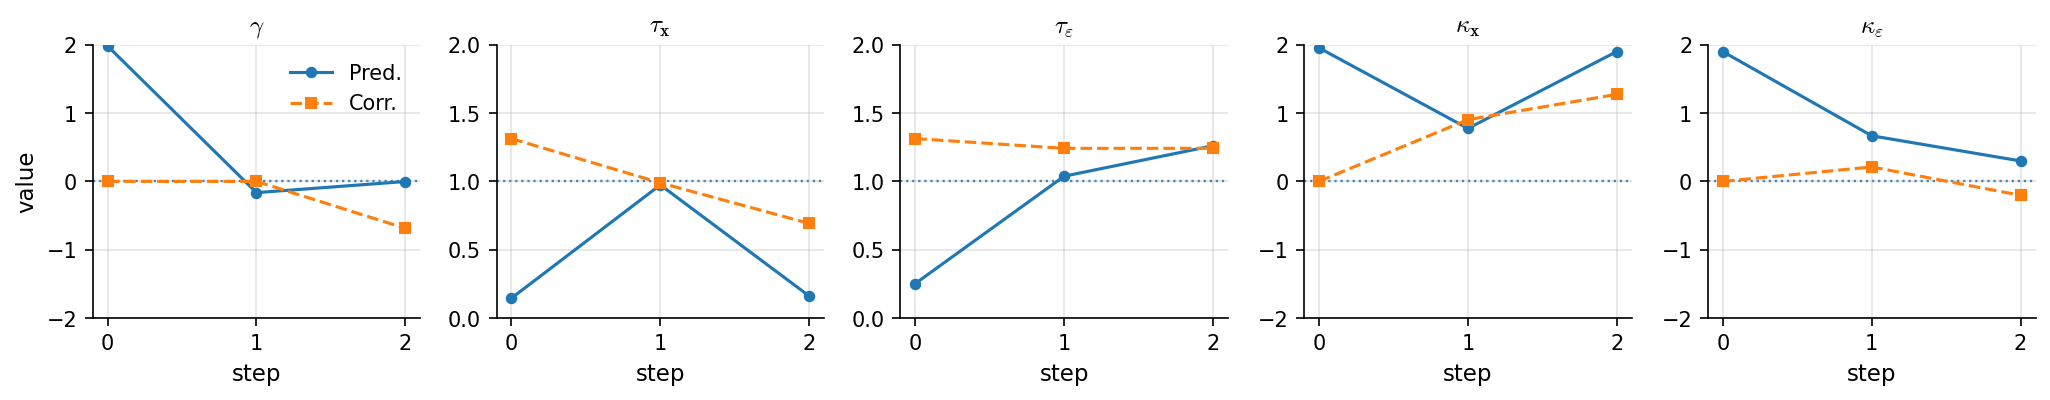

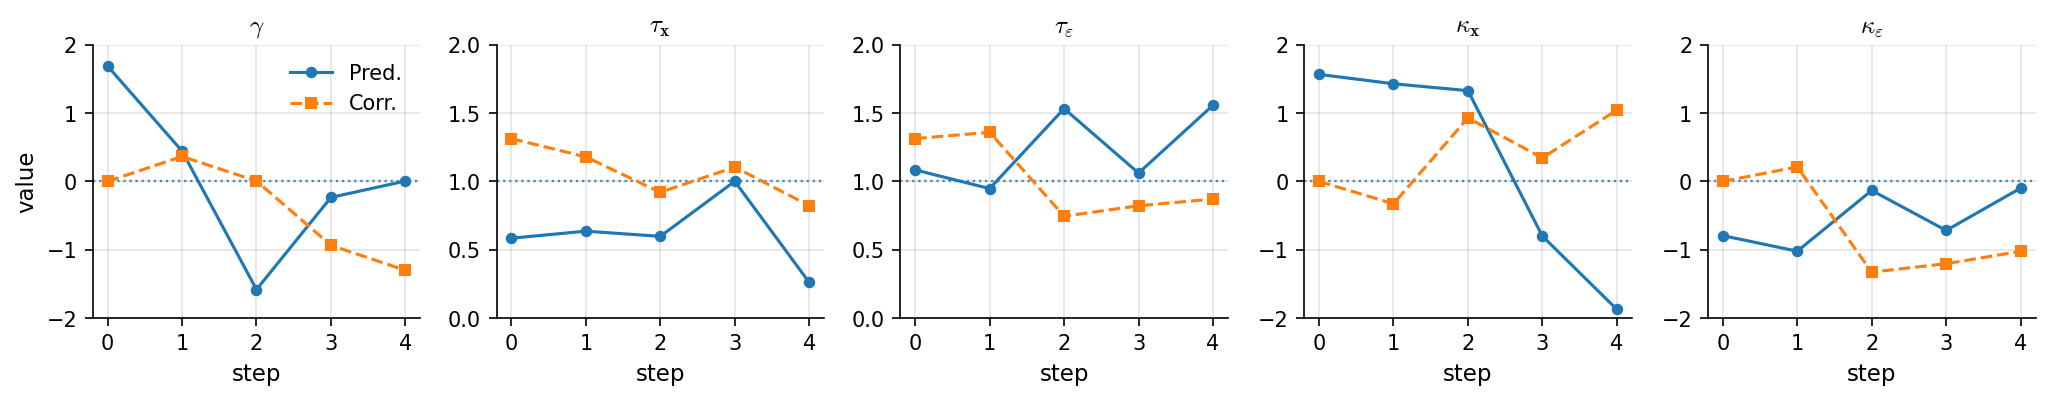

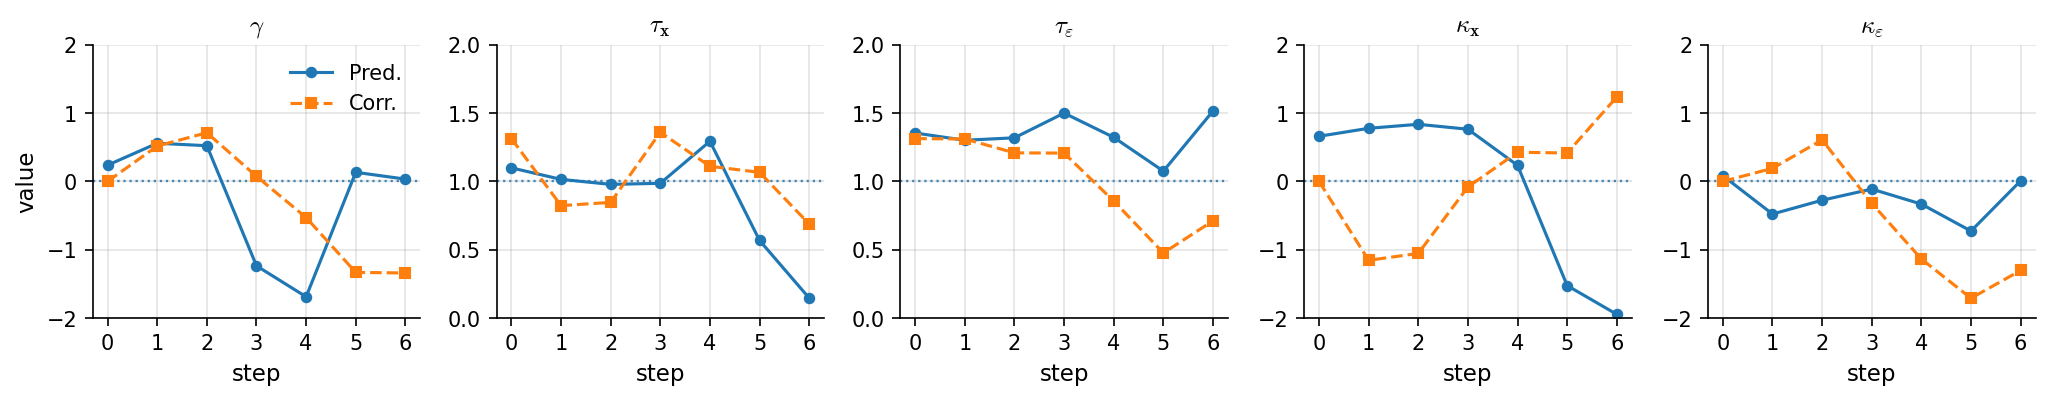

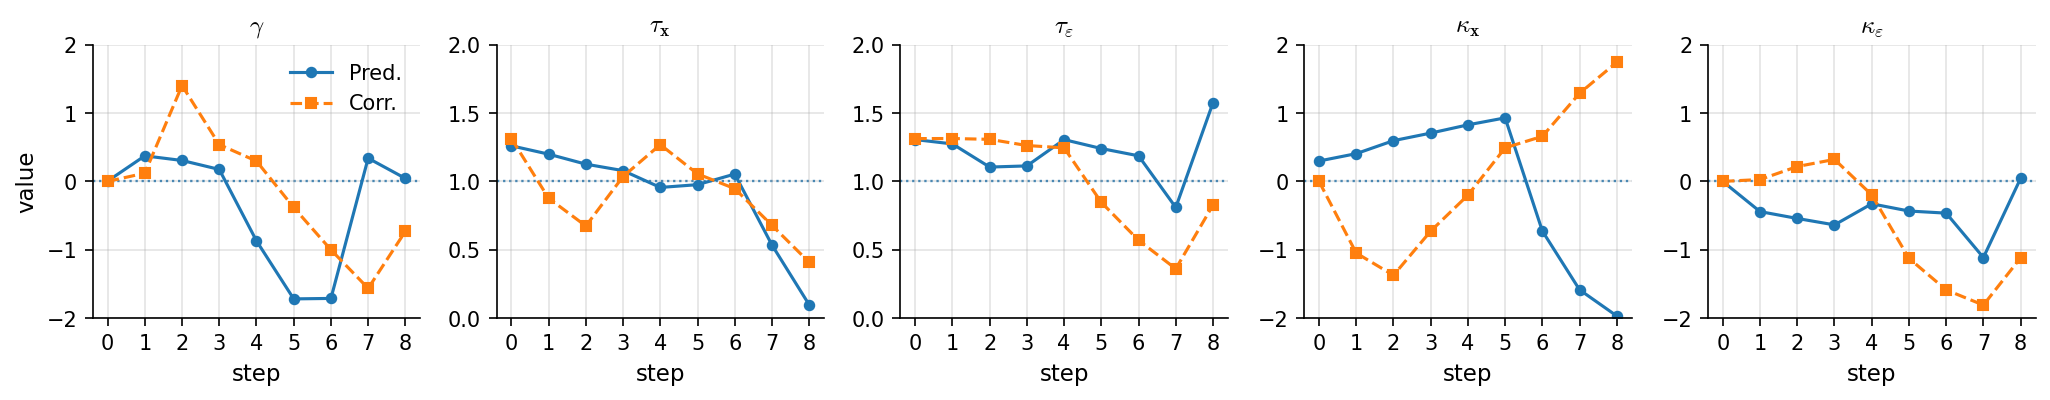

In [90]:
PATH = 'logs/ablations/multi3/s3/step_00020000.pt'
plot_solver_params(PATH) # NFE=3
PATH = 'logs/ablations/multi3/s5/step_00020000.pt'
plot_solver_params(PATH) # NFE=5
PATH = 'logs/ablations/multi3/s7/step_00020000.pt'
plot_solver_params(PATH) # NFE=7
PATH = 'logs/ablations/multi3/s9/step_00020000.pt'
plot_solver_params(PATH) # NFE=9
